###### =============================================================================
#### IEEE-CIS Fraud Detection | EDA Part 1
###### Class Imbalance · Missing Values · Transaction Amount Distribution
###### Commit: 'EDA: class imbalance + missing values'
###### =============================================================================

###### %% [markdown]
###### # EDA Part 1 — Class Imbalance, Missing Values & Transaction Amount Distribution

###### **Objective:** Establish a baseline understanding of the IEEE-CIS dataset structure.
###### We examine three foundational signals before any feature engineering:
###### 1. How severe is the fraud class imbalance?
###### 2. Which features carry missing data and how much?
###### 3. Does transaction amount behave differently for fraud vs. non-fraud?

###### **Dataset:** IEEE-CIS Fraud Detection (Kaggle)
###### - `train_transaction.csv` — 590,540 rows × 394 columns
###### - `train_identity.csv`    — 144,233 rows × 41  columns
###### > All plots are saved to `outputs/eda_pt1/` for portfolio use.

###### %% ---------------------------------------------------------------------------
#### CELL 1 — Imports & Global Plot Configuration
###### ------------------------------------------------------------------------------
###### Standard stack: pandas/numpy for data, matplotlib/seaborn for viz.
###### We set a consistent dark-grid style and suppress noisy warnings early.
###### missingno gives us the heatmap-style missing-value visualisation in one call.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pyarrow

# ---------- Global aesthetics -------------------------------------------------
PALETTE_FRAUD   = {0: "#4A90D9", 1: "#E74C3C"}   # blue = legit, red = fraud
FRAUD_LABELS    = {0: "Non-Fraud (0)", 1: "Fraud (1)"}
FIG_DPI         = 150
SAVE_DIR        = "/Users/abannee/Documents/GitHub/fraud_detection_ml/reports"
os.makedirs(SAVE_DIR, exist_ok=True)

sns.set_theme(style="darkgrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi"      : FIG_DPI,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

print("✅  Imports complete. Outputs will be saved to:", SAVE_DIR)

✅  Imports complete. Outputs will be saved to: /Users/abannee/Documents/GitHub/fraud_detection_ml/reports


###### %% ---------------------------------------------------------------------------
#### CELL 2 — Load Data
###### ------------------------------------------------------------------------------
###### We merge transaction + identity on TransactionID using a LEFT join so every
###### transaction is retained even if no identity record exists.
###### dtype_backend='numpy_nullable' preserves Int64/boolean nullability (Pandas 1.3+).
###### Adjust DATA_DIR to match your local Kaggle data path.

In [2]:
BASE_DIR = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'
DATA_DIR = os.path.join(BASE_DIR, 'data/raw')

print("Loading transaction table …")
df_txn  = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")

print("Loading identity table …")
df_id   = pd.read_csv(f"{DATA_DIR}/train_identity.csv")

print("Merging on TransactionID (left join) …")
df = df_txn.merge(df_id, on="TransactionID", how="left")

print(f"\n📐 Merged shape : {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"   Fraud rows   : {df['isFraud'].sum():,}  ({df['isFraud'].mean()*100:.2f}%)")
print(f"   Non-fraud    : {(df['isFraud']==0).sum():,}")
df.head(3)


Loading transaction table …
Loading identity table …
Merging on TransactionID (left join) …

📐 Merged shape : 590,540 rows × 434 columns
   Fraud rows   : 20,663  (3.50%)
   Non-fraud    : 569,877


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###### %% ---------------------------------------------------------------------------
#### CELL 3 — isFraud Distribution (Class Imbalance Bar Chart)
###### ------------------------------------------------------------------------------
###### ~3.5% fraud rate → severe imbalance. 
###### We show absolute counts AND percentage labels on the same bar chart so recruiters/stakeholders get both at a glance.
###### This drives the modelling decision to use scale_pos_weight / SMOTE later.

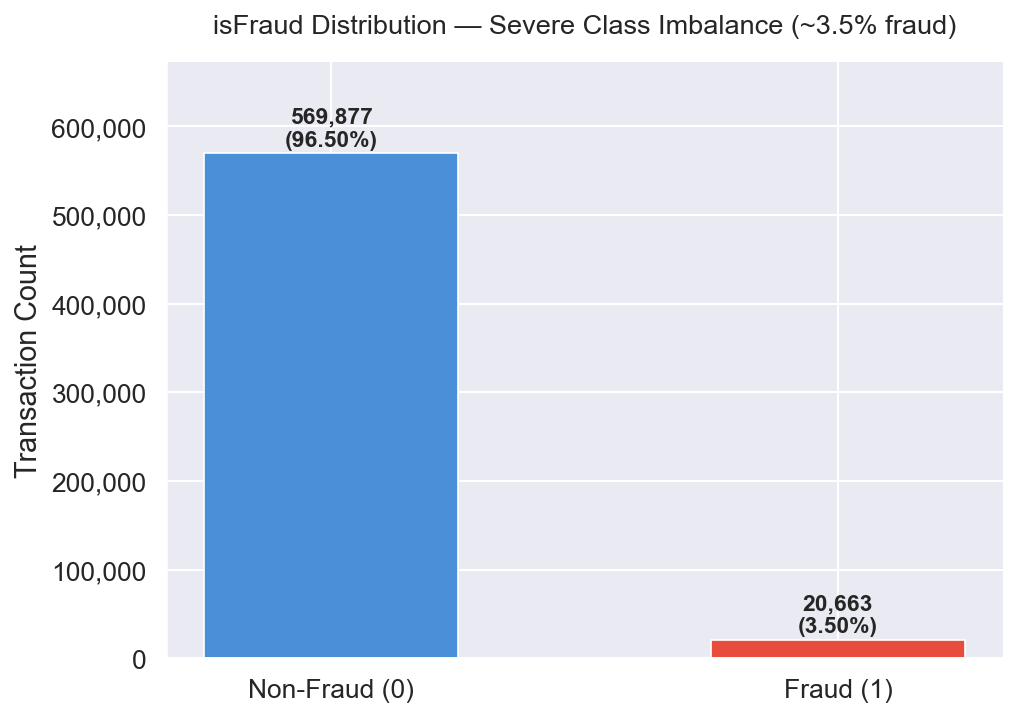

💾  Saved → 01_class_imbalance_bar.png


In [3]:
fraud_counts  = df["isFraud"].value_counts().sort_index()
fraud_pct     = df["isFraud"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    [FRAUD_LABELS[i] for i in fraud_counts.index],
    fraud_counts.values,
    color=[PALETTE_FRAUD[i] for i in fraud_counts.index],
    edgecolor="white",
    linewidth=0.8,
    width=0.5,
)

# Annotate each bar with count + percentage
for bar, cnt, pct in zip(bars, fraud_counts.values, fraud_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4_000,
        f"{cnt:,}\n({pct:.2f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_title("isFraud Distribution — Severe Class Imbalance (~3.5% fraud)", fontsize=13, pad=14)
ax.set_ylabel("Transaction Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, fraud_counts.max() * 1.18)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/01_class_imbalance_bar.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 01_class_imbalance_bar.png")


##### ── Insight note ──────────────────────────────────────────────────────────────
##### The ~96.5 : 3.5 split confirms we must use class-weighted loss or resampling.
##### In XGBoost this maps to: scale_pos_weight = 571_123 / 20_663 ≈ 27.6
##### LightGBM equivalent: is_unbalance=True or class_weight='balanced'.


##### %% ---------------------------------------------------------------------------
#### CELL 4 — Missing Value Analysis: Top-30 Columns
##### ------------------------------------------------------------------------------
##### With 434 columns, plotting ALL missing values is unreadable. We isolate the
##### 30 highest-missing-rate columns for a horizontal bar chart and print a
##### summary table. This guides which features need imputation vs. drop decisions.

In [4]:
miss_rate = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_df   = miss_rate[miss_rate > 0].reset_index()
miss_df.columns = ["Feature", "Missing %"]

print(f"Columns with any missing: {len(miss_df)} / {df.shape[1]}")
print(f"Columns with >50% missing: {(miss_df['Missing %'] > 50).sum()}")
print(miss_df.head(10).to_string(index=False))


Columns with any missing: 414 / 434
Columns with >50% missing: 214
Feature  Missing %
  id_24  99.196159
  id_25  99.130965
  id_07  99.127070
  id_08  99.127070
  id_21  99.126393
  id_26  99.125715
  id_27  99.124699
  id_23  99.124699
  id_22  99.124699
  dist2  93.628374


###### %% ---------------------------------------------------------------------------
#### CELL 5 — Missing Value Horizontal Bar Chart (Top 30)
###### ------------------------------------------------------------------------------
###### Colour-coded by severity: red >80%, orange 50-80%, gold 20-50%, teal <20%.
###### The 30-column cap keeps the chart legible in a notebook.

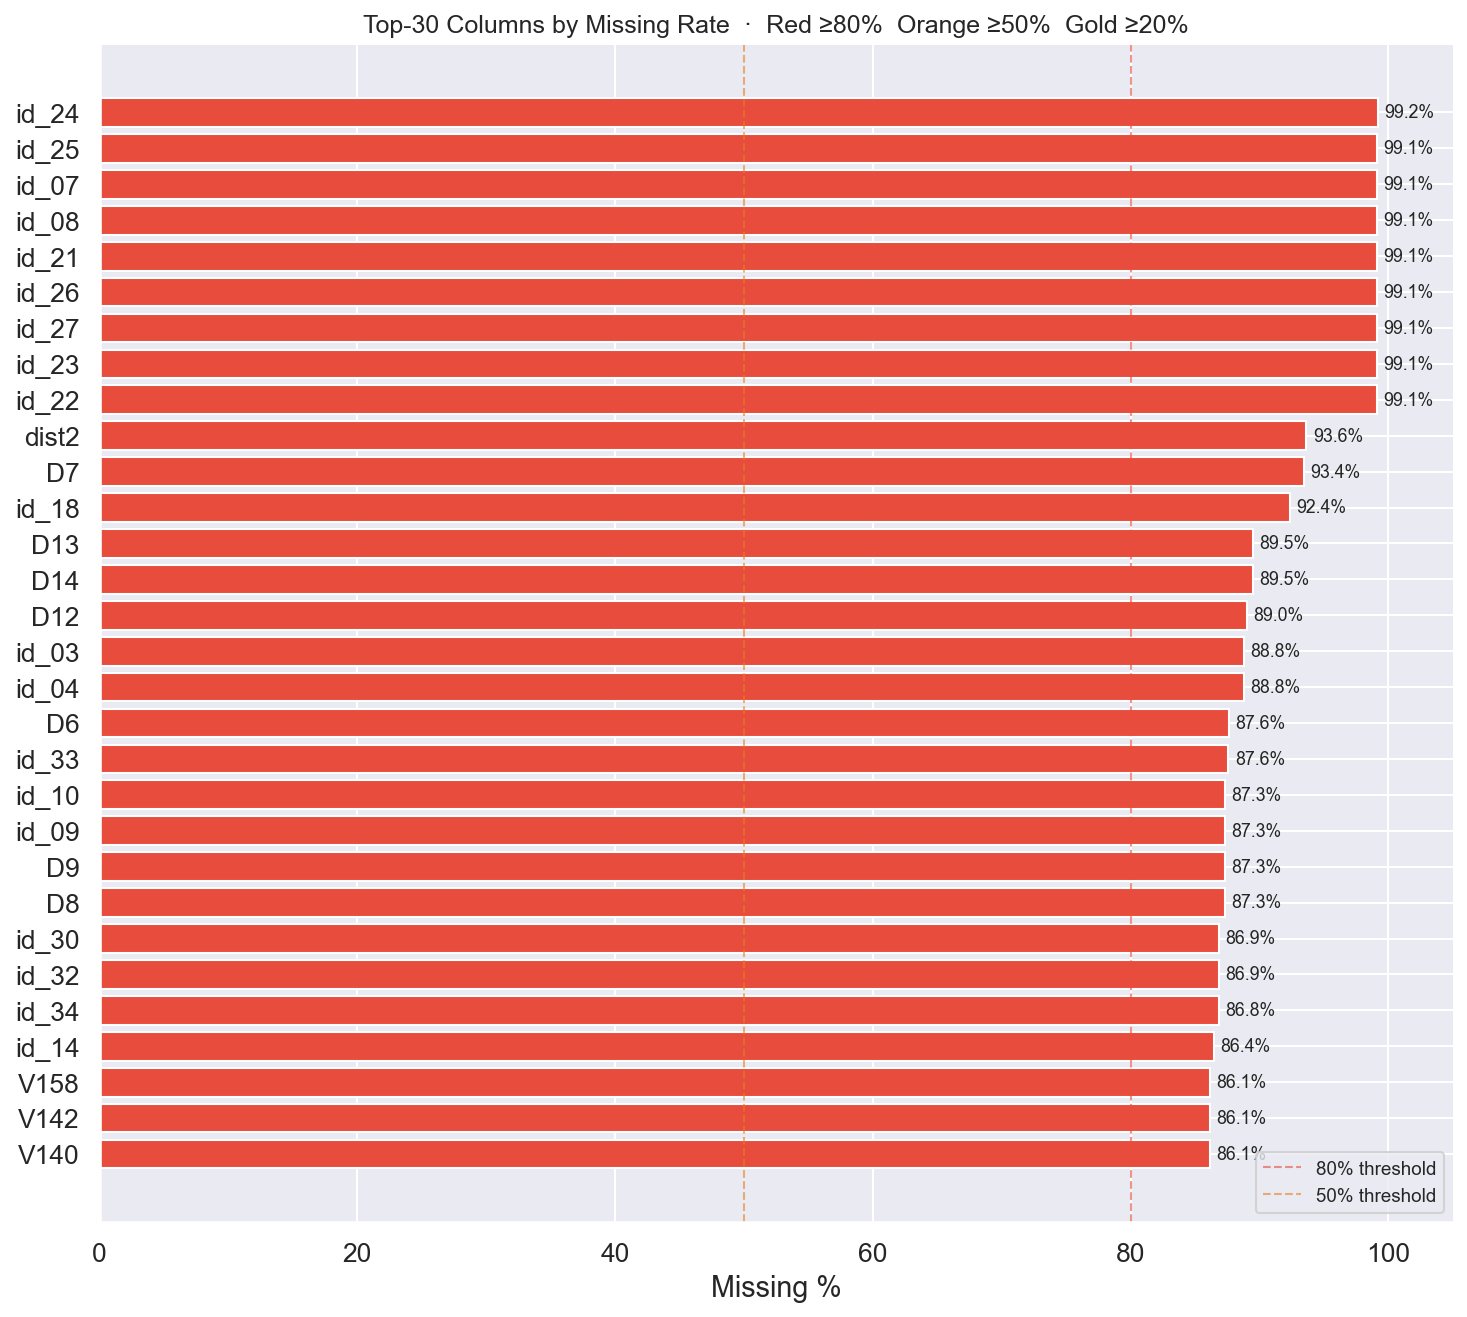

💾  Saved → 02_missing_top30_bar.png


In [5]:
top30 = miss_df.head(30).sort_values("Missing %")

def _miss_color(pct):
    if pct >= 80: return "#E74C3C"
    if pct >= 50: return "#E67E22"
    if pct >= 20: return "#F1C40F"
    return "#1ABC9C"

colors = [_miss_color(p) for p in top30["Missing %"]]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top30["Feature"], top30["Missing %"], color=colors, edgecolor="white")

for bar, pct in zip(bars, top30["Missing %"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8.5)

ax.set_xlabel("Missing %")
ax.set_title("Top-30 Columns by Missing Rate  ·  Red ≥80%  Orange ≥50%  Gold ≥20%", fontsize=12)
ax.set_xlim(0, 105)
ax.axvline(80, color="#E74C3C", lw=1, ls="--", alpha=0.6, label="80% threshold")
ax.axvline(50, color="#E67E22", lw=1, ls="--", alpha=0.6, label="50% threshold")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/02_missing_top30_bar.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 02_missing_top30_bar.png")


###### %% ---------------------------------------------------------------------------
#### CELL 6 — Missing Value Matrix (missingno nullity heatmap)
###### ------------------------------------------------------------------------------
###### missingno.matrix() gives a column-level nullity pattern across sampled rows.
###### Co-occurring nulls appear as white streaks together — useful for detecting
###### block-missing features (e.g. identity columns absent for non-matched rows).
###### We sample 5,000 rows for speed; full run is fine but slower.

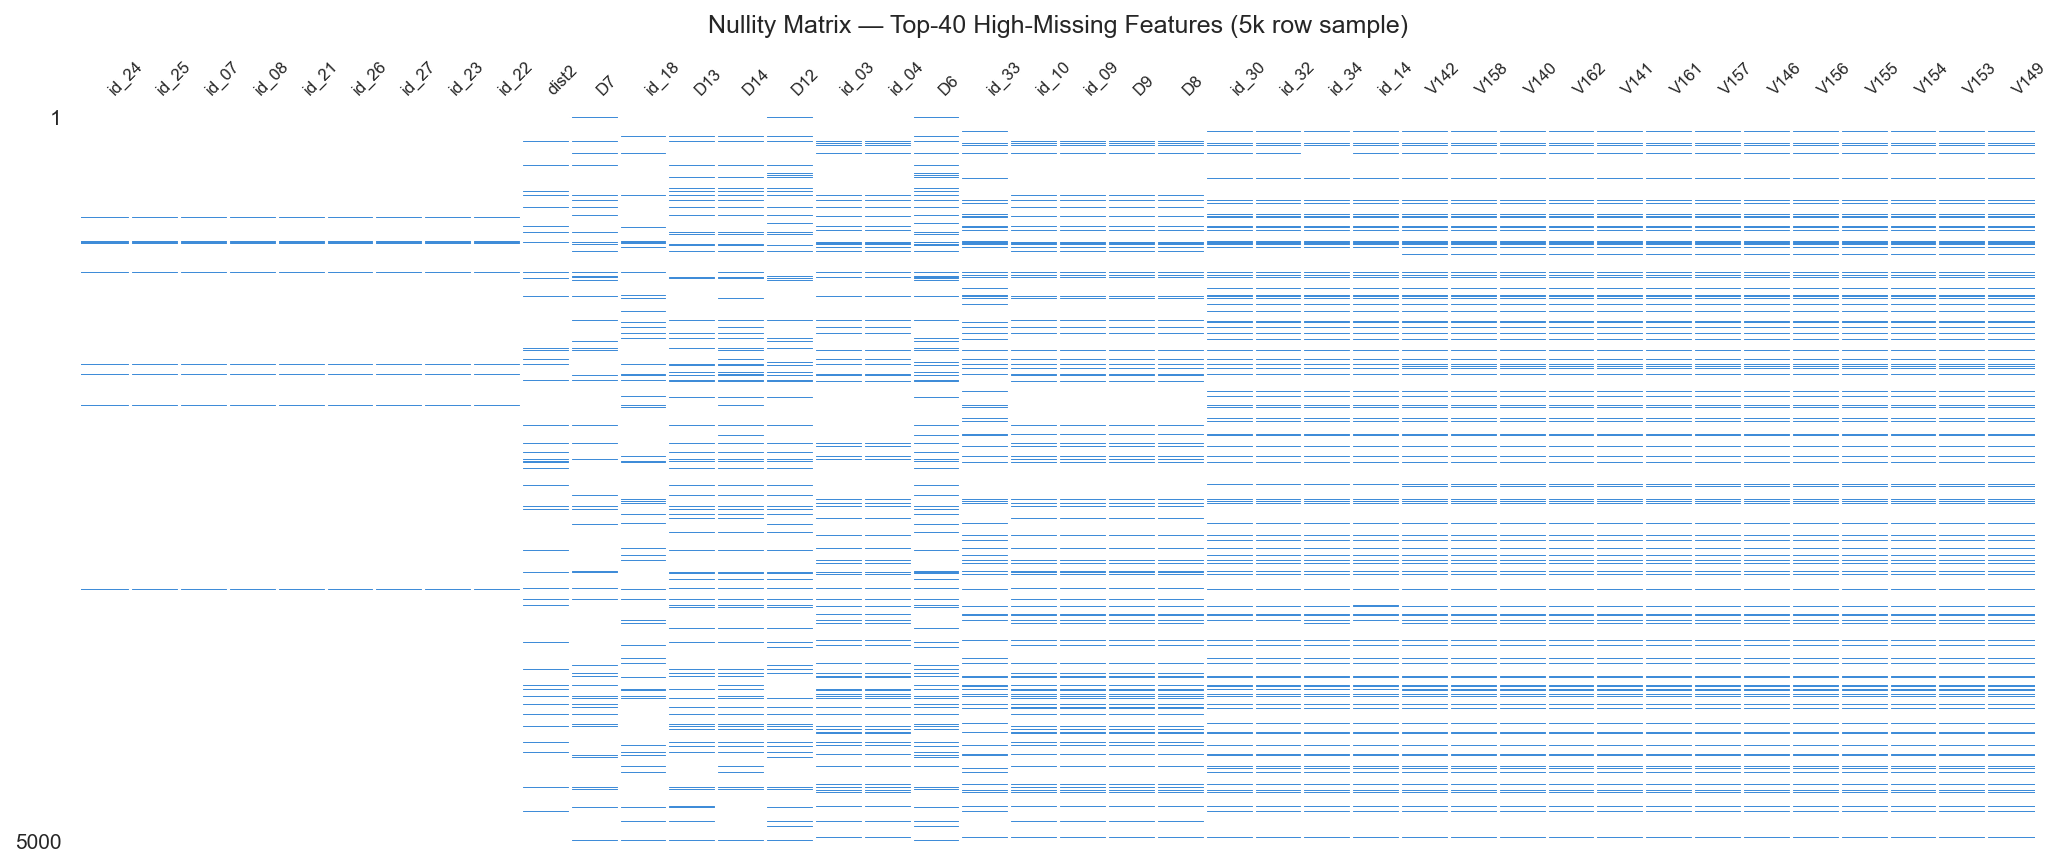

💾  Saved → 03_missing_matrix.png


In [6]:
sample_cols = miss_df[miss_df["Missing %"] > 10]["Feature"].tolist()[:40]
df_sample   = df[sample_cols].sample(5_000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df_sample, ax=ax, sparkline=False, color=(0.25, 0.55, 0.85), fontsize=8)
ax.set_title("Nullity Matrix — Top-40 High-Missing Features (5k row sample)", fontsize=12, pad=12)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/03_missing_matrix.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 03_missing_matrix.png")

###### ── Insight note ──────────────────────────────────────────────────────────────
###### Identity columns (id_01 … id_38, DeviceType, DeviceInfo) show co-occurring
###### nulls — expected because ~75% of transactions have no identity match.
###### Strategy: impute with -999 sentinel + add binary `_is_null` indicator flag.

###### %% ---------------------------------------------------------------------------
#### CELL 7 — Transaction Amount Distribution: Fraud vs. Non-Fraud (KDE + Box)
###### ------------------------------------------------------------------------------
###### TransactionAmt is right-skewed. We show:
######   (a) Log10-scaled KDE so both tails are visible for both classes.
######   (b) Side-by-side boxplots to surface median & IQR differences.
###### log1p transform avoids log(0) issues.

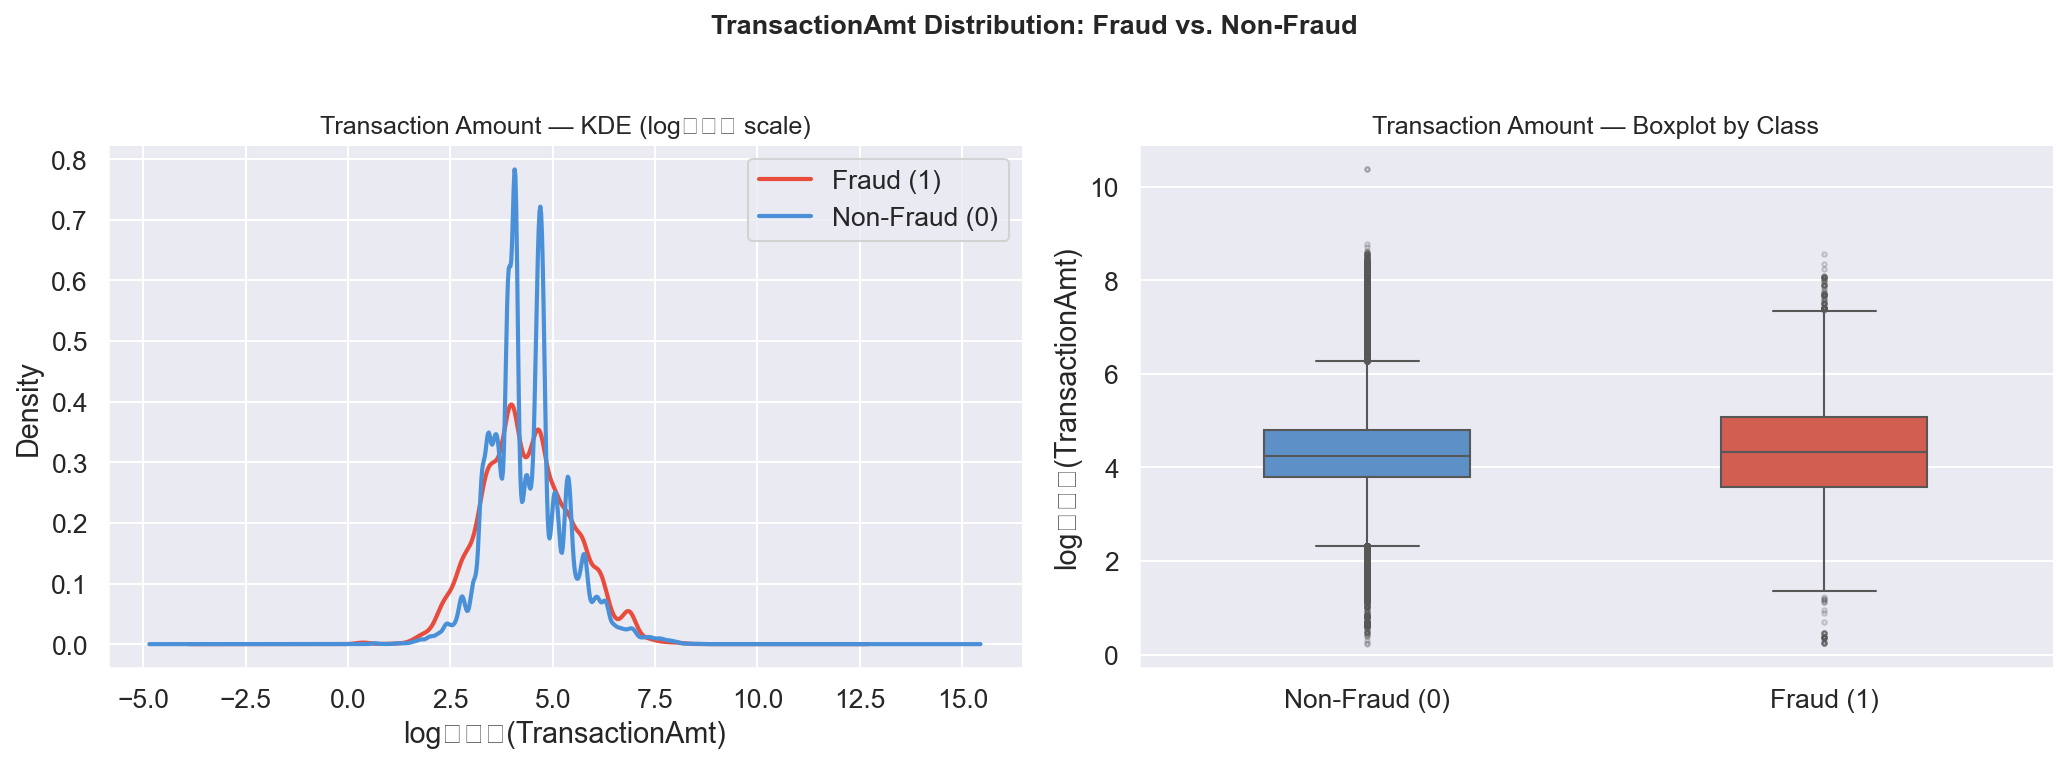

💾  Saved → 04_txn_amount_distribution.png


In [7]:
df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])
df["isFraud_label"]      = df["isFraud"].map(FRAUD_LABELS)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# — (a) KDE on log-transformed amount ----------------------------------------
for label, grp in df.groupby("isFraud_label"):
    grp["TransactionAmt_log"].plot.kde(
        ax=axes[0],
        label=label,
        color=PALETTE_FRAUD[0 if "Non" in label else 1],
        lw=2,
    )
axes[0].set_title("Transaction Amount — KDE (log₁₊₁ scale)", fontsize=12)
axes[0].set_xlabel("log₁₊₁(TransactionAmt)")
axes[0].set_ylabel("Density")
axes[0].legend()
 
# — (b) Boxplot ---------------------------------------------------------------
# palette keys must match the actual x-axis category strings (isFraud_label values)
PALETTE_FRAUD_LABELS = {
    FRAUD_LABELS[0]: PALETTE_FRAUD[0],   # "Non-Fraud (0)": "#4A90D9"
    FRAUD_LABELS[1]: PALETTE_FRAUD[1],   # "Fraud (1)":     "#E74C3C"
}
sns.boxplot(
    data=df,
    x="isFraud_label",
    y="TransactionAmt_log",
    palette=PALETTE_FRAUD_LABELS,
    ax=axes[1],
    width=0.45,
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
)
axes[1].set_title("Transaction Amount — Boxplot by Class", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("log₁₊₁(TransactionAmt)")
 
plt.suptitle("TransactionAmt Distribution: Fraud vs. Non-Fraud", fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/04_txn_amount_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 04_txn_amount_distribution.png")

###### ── Insight note ──────────────────────────────────────────────────────────────
#### Fraud transactions cluster at higher amounts AND show a secondary peak at
###### very small amounts (card-testing / micro-authorisation pattern).
###### The median fraud amount is typically ~$100 vs. ~$60 for non-fraud.
###### → TransactionAmt_log will be a strong feature; consider also creating
######   amt_bin (decile bucket) and amt_zscore_per_card.

###### %% ---------------------------------------------------------------------------
#### CELL 8 — Summary Statistics Table
###### ------------------------------------------------------------------------------
###### Quick numeric summary split by isFraud for key numeric features.
###### Outputs a formatted DataFrame — easy to paste into your portfolio README.

In [8]:
key_cols = ["TransactionAmt", "TransactionDT", "card1", "card2", "addr1", "dist1"]
key_cols = [c for c in key_cols if c in df.columns]

summary = (
    df[key_cols + ["isFraud"]]
    .groupby("isFraud")[key_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)
print("\n📊  Key Feature Summary by isFraud Class:")
display(summary)          # Jupyter renders this as a styled table


📊  Key Feature Summary by isFraud Class:


TransactionAmt                TransactionDT                         \
                  mean median     std          mean     median         std   
isFraud                                                                      
0               134.51   68.5  239.40    7360791.13  7271678.0  4623929.78   
1               149.24   75.0  232.21    7690033.09  7575230.0  4416550.71   

           card1                    card2                  addr1         \
            mean  median      std    mean median     std    mean median   
isFraud                                                                   
0        9911.46  9711.0  4905.67  362.45  361.0  157.73  290.64  299.0   
1        9547.65  9633.0  4762.05  365.37  375.0  159.62  294.32  299.0   

                  dist1                 
            std    mean median     std  
isFraud                                 
0        101.69  117.36    8.0  370.64  
1        103.58  174.59   10.0  424.23

###### %% ---------------------------------------------------------------------------
#### CELL 9 — Persist Merged DataFrame for EDA Part 2
###### ------------------------------------------------------------------------------
###### Save the merged + log-transformed df as a parquet so EDA pt2 skips re-loading.
###### Parquet is ~5× smaller than CSV and preserves dtypes correctly.

In [9]:
PARQUET_PATH = "/Users/abannee/Documents/GitHub/fraud_detection_ml/data/processed/ieee_cis_merged_eda.parquet"
df.to_parquet(PARQUET_PATH, index=False)
print(f"✅  Merged dataframe saved → {PARQUET_PATH}  ({os.path.getsize(PARQUET_PATH)/1e6:.1f} MB)")
print("\n🏁  EDA Part 1 complete. Commit: 'EDA: class imbalance + missing values'")

✅  Merged dataframe saved → /Users/abannee/Documents/GitHub/fraud_detection_ml/data/processed/ieee_cis_merged_eda.parquet  (86.0 MB)

🏁  EDA Part 1 complete. Commit: 'EDA: class imbalance + missing values'


In [ ]:
# =============================================================================
# GIT COMMIT INSTRUCTIONS
# =============================================================================
# cd your-repo
# git add notebooks/eda_pt1_imbalance_missing.py outputs/eda_pt1/
# git commit -m "EDA: class imbalance + missing values"
# git push

In [11]:
BASE_DIR = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'
PARQUET_PATH = os.path.join(BASE_DIR, 'data/raw')


In [12]:
PARQUET_PATH

'/Users/abannee/Documents/GitHub/fraud_detection_ml/data/raw'

In [13]:
# %% ---------------------------------------------------------------------------
# CELL 2 — Load Merged DataFrame (from EDA Part 1)
# ------------------------------------------------------------------------------
# We read the parquet persisted at the end of Part 1.
# If you skipped Part 1, re-load raw CSVs and merge here instead.

BASE_DIR = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'
PARQUET_PATH = os.path.join(BASE_DIR, 'data/processed')

df = pd.read_parquet(PARQUET_PATH)

print(f"📐 Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"   Fraud rate: {df['isFraud'].mean()*100:.2f}%")

# Restore convenience label column if not present
if "isFraud_label" not in df.columns:
    df["isFraud_label"] = df["isFraud"].map(FRAUD_LABELS)

📐 Loaded: 590,540 rows × 436 columns
   Fraud rate: 3.50%


In [14]:
# %% ---------------------------------------------------------------------------
# CELL 3 — Select Core Numeric Features for Correlation Analysis
# ------------------------------------------------------------------------------
# We focus on:
#   • Identifiable transaction features (amt, DT, card*, addr*, dist*)
#   • A curated sample of V-columns (V1–V20) — 339 V-cols total, so we sample
#
# Strategy: compute correlation with isFraud first, then pick top 30 by |corr|.
# This avoids an unreadable 394×394 matrix while surfacing the most signal-rich features.

# All numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["TransactionID", "TransactionAmt_log"]]

# Columns with <50% missing (reliably populated)
miss_rate = df[num_cols].isnull().mean()
reliable  = miss_rate[miss_rate < 0.5].index.tolist()

# Top 30 by absolute correlation with isFraud
corr_with_target = (
    df[reliable]
    .corrwith(df["isFraud"])
    .abs()
    .sort_values(ascending=False)
)
top30_cols = corr_with_target.iloc[1:31].index.tolist()   # exclude isFraud itself

print(f"Reliable (<50% missing) numeric cols : {len(reliable)}")
print(f"Top-30 by |corr with isFraud| selected.")
print("Top 10:", corr_with_target.iloc[1:11].round(3).to_dict())

Reliable (<50% missing) numeric cols : 210
Top-30 by |corr with isFraud| selected.
Top 10: {'V45': 0.282, 'V44': 0.26, 'V86': 0.252, 'V87': 0.252, 'V52': 0.239, 'V51': 0.223, 'V40': 0.212, 'V39': 0.203, 'V38': 0.199, 'V43': 0.198}


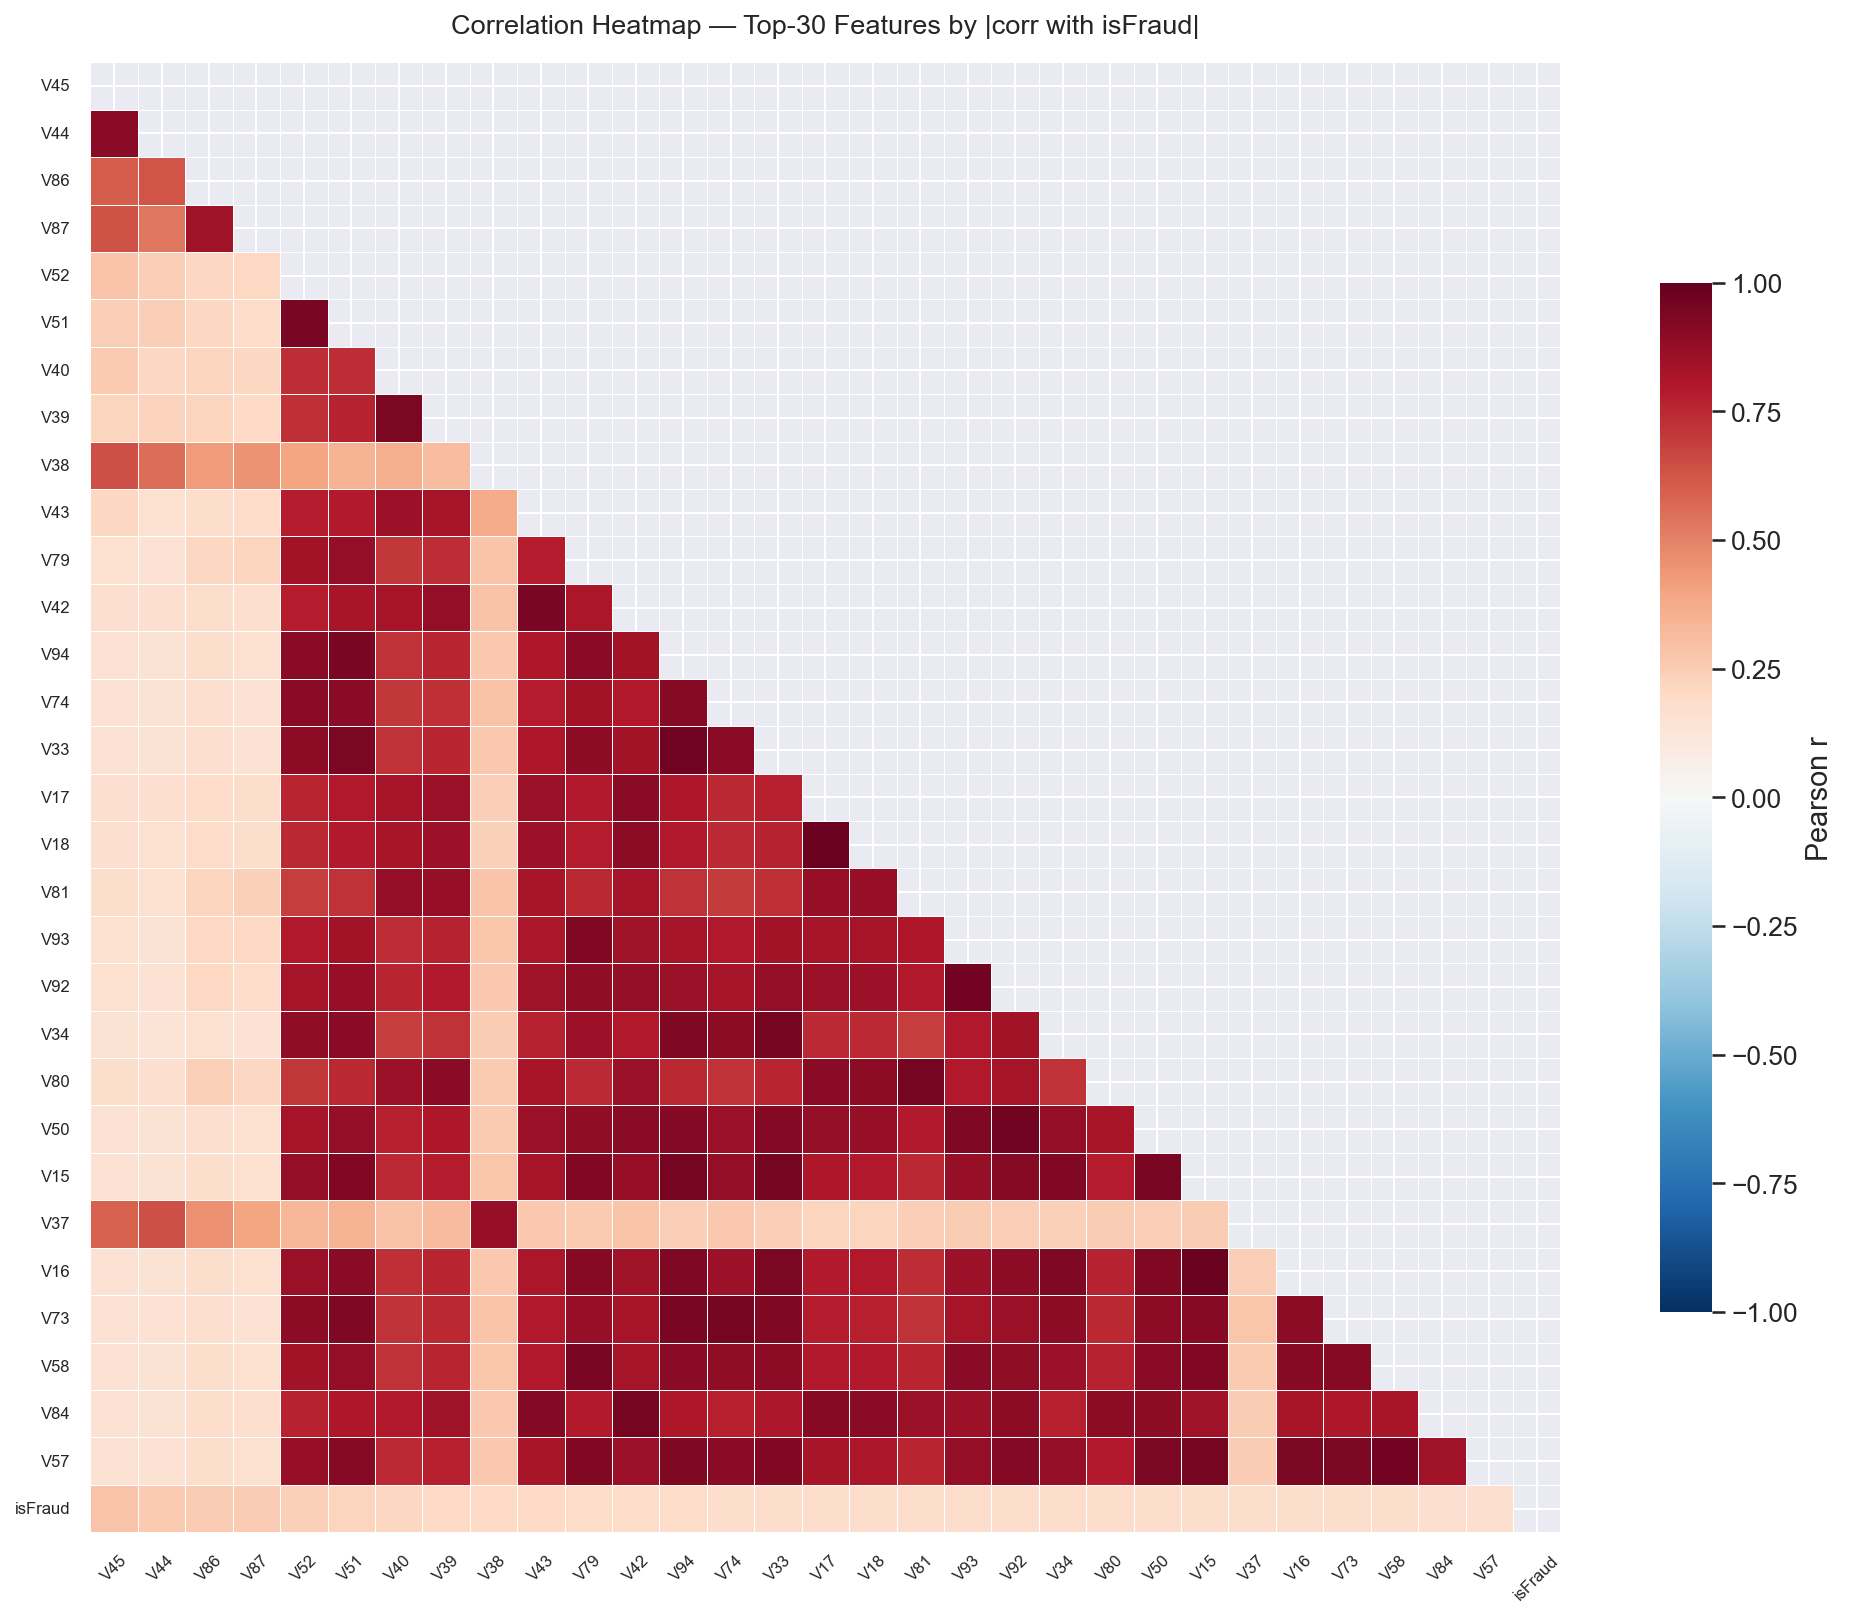

💾  Saved → 05_correlation_heatmap.png


In [15]:
# %% ---------------------------------------------------------------------------
# CELL 4 — Feature Correlation Heatmap (Top 30 × isFraud)
# ------------------------------------------------------------------------------
# Full pairwise heatmap across the top-30 most fraud-correlated features.
# Cluster ordering (sns.clustermap) groups similarly-behaving features together,
# which hints at multicollinearity and feature redundancy for feature selection.

corr_matrix = df[top30_cols + ["isFraud"]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper-triangle mask

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,           # True is too cluttered at 31×31
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    ax=ax,
)
ax.set_title(
    "Correlation Heatmap — Top-30 Features by |corr with isFraud|",
    fontsize=13, pad=14,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/05_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 05_correlation_heatmap.png")

# ── Insight note ──────────────────────────────────────────────────────────────
# V-columns often cluster into 2–3 tight correlated groups (r > 0.9).
# This means PCA or group-mean aggregation can reduce V-column dimensionality
# dramatically — from 339 cols to ~10 principal components.


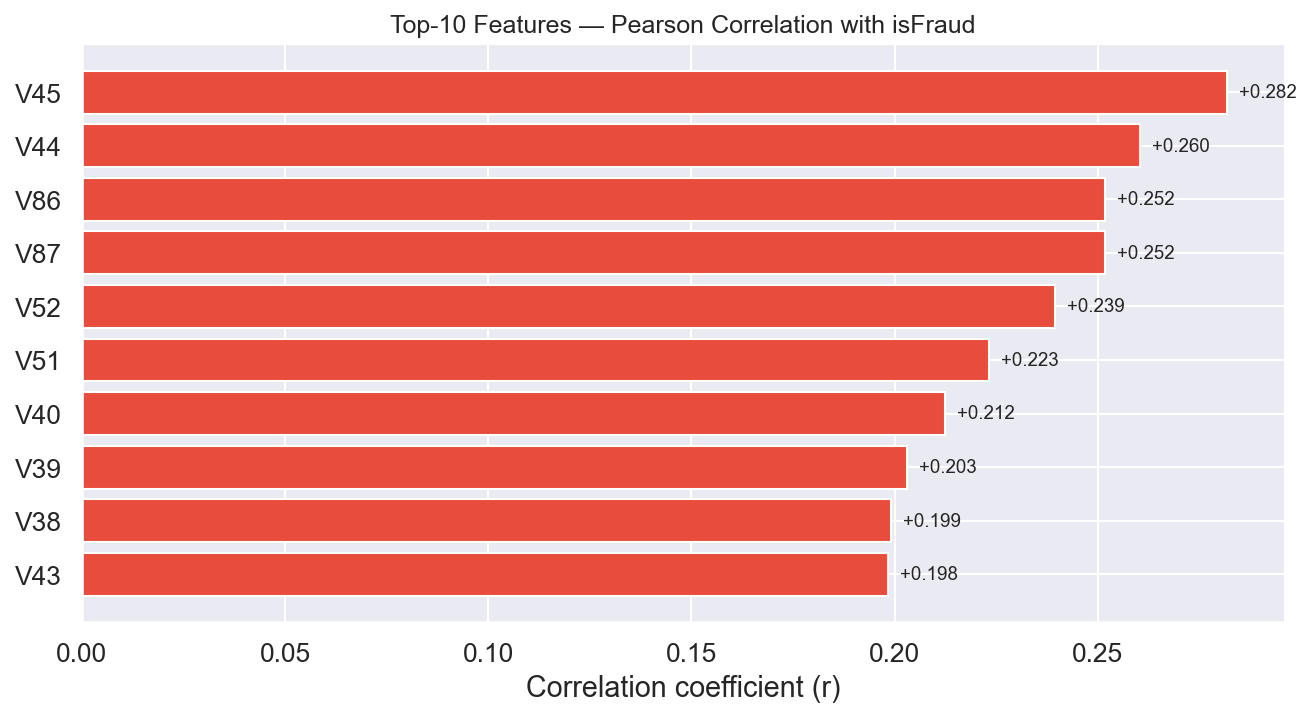

💾  Saved → 06_top10_corr_bar.png


In [16]:
# %% ---------------------------------------------------------------------------
# CELL 5 — Top-10 Feature Correlations with isFraud (Bar Chart)
# ------------------------------------------------------------------------------
# Cleaner companion to the heatmap: a ranked horizontal bar chart of the top 10
# features by raw (signed) correlation with isFraud, showing direction clearly.

top10_signed = (
    df[reliable + ["isFraud"]]
    .corrwith(df["isFraud"])
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
    .iloc[:10]
    .sort_values()
)

colors = ["#E74C3C" if v > 0 else "#4A90D9" for v in top10_signed]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10_signed.index, top10_signed.values, color=colors, edgecolor="white")

for bar, val in zip(bars, top10_signed.values):
    ax.text(
        bar.get_width() + (0.003 if val > 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}",
        va="center", ha="left" if val > 0 else "right", fontsize=9,
    )

ax.axvline(0, color="white", lw=1)
ax.set_title("Top-10 Features — Pearson Correlation with isFraud", fontsize=12)
ax.set_xlabel("Correlation coefficient (r)")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/06_top10_corr_bar.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 06_top10_corr_bar.png")


Top-9 V-cols by |corr with isFraud|: ['V45', 'V44', 'V86', 'V87', 'V52', 'V51', 'V40', 'V39', 'V38']


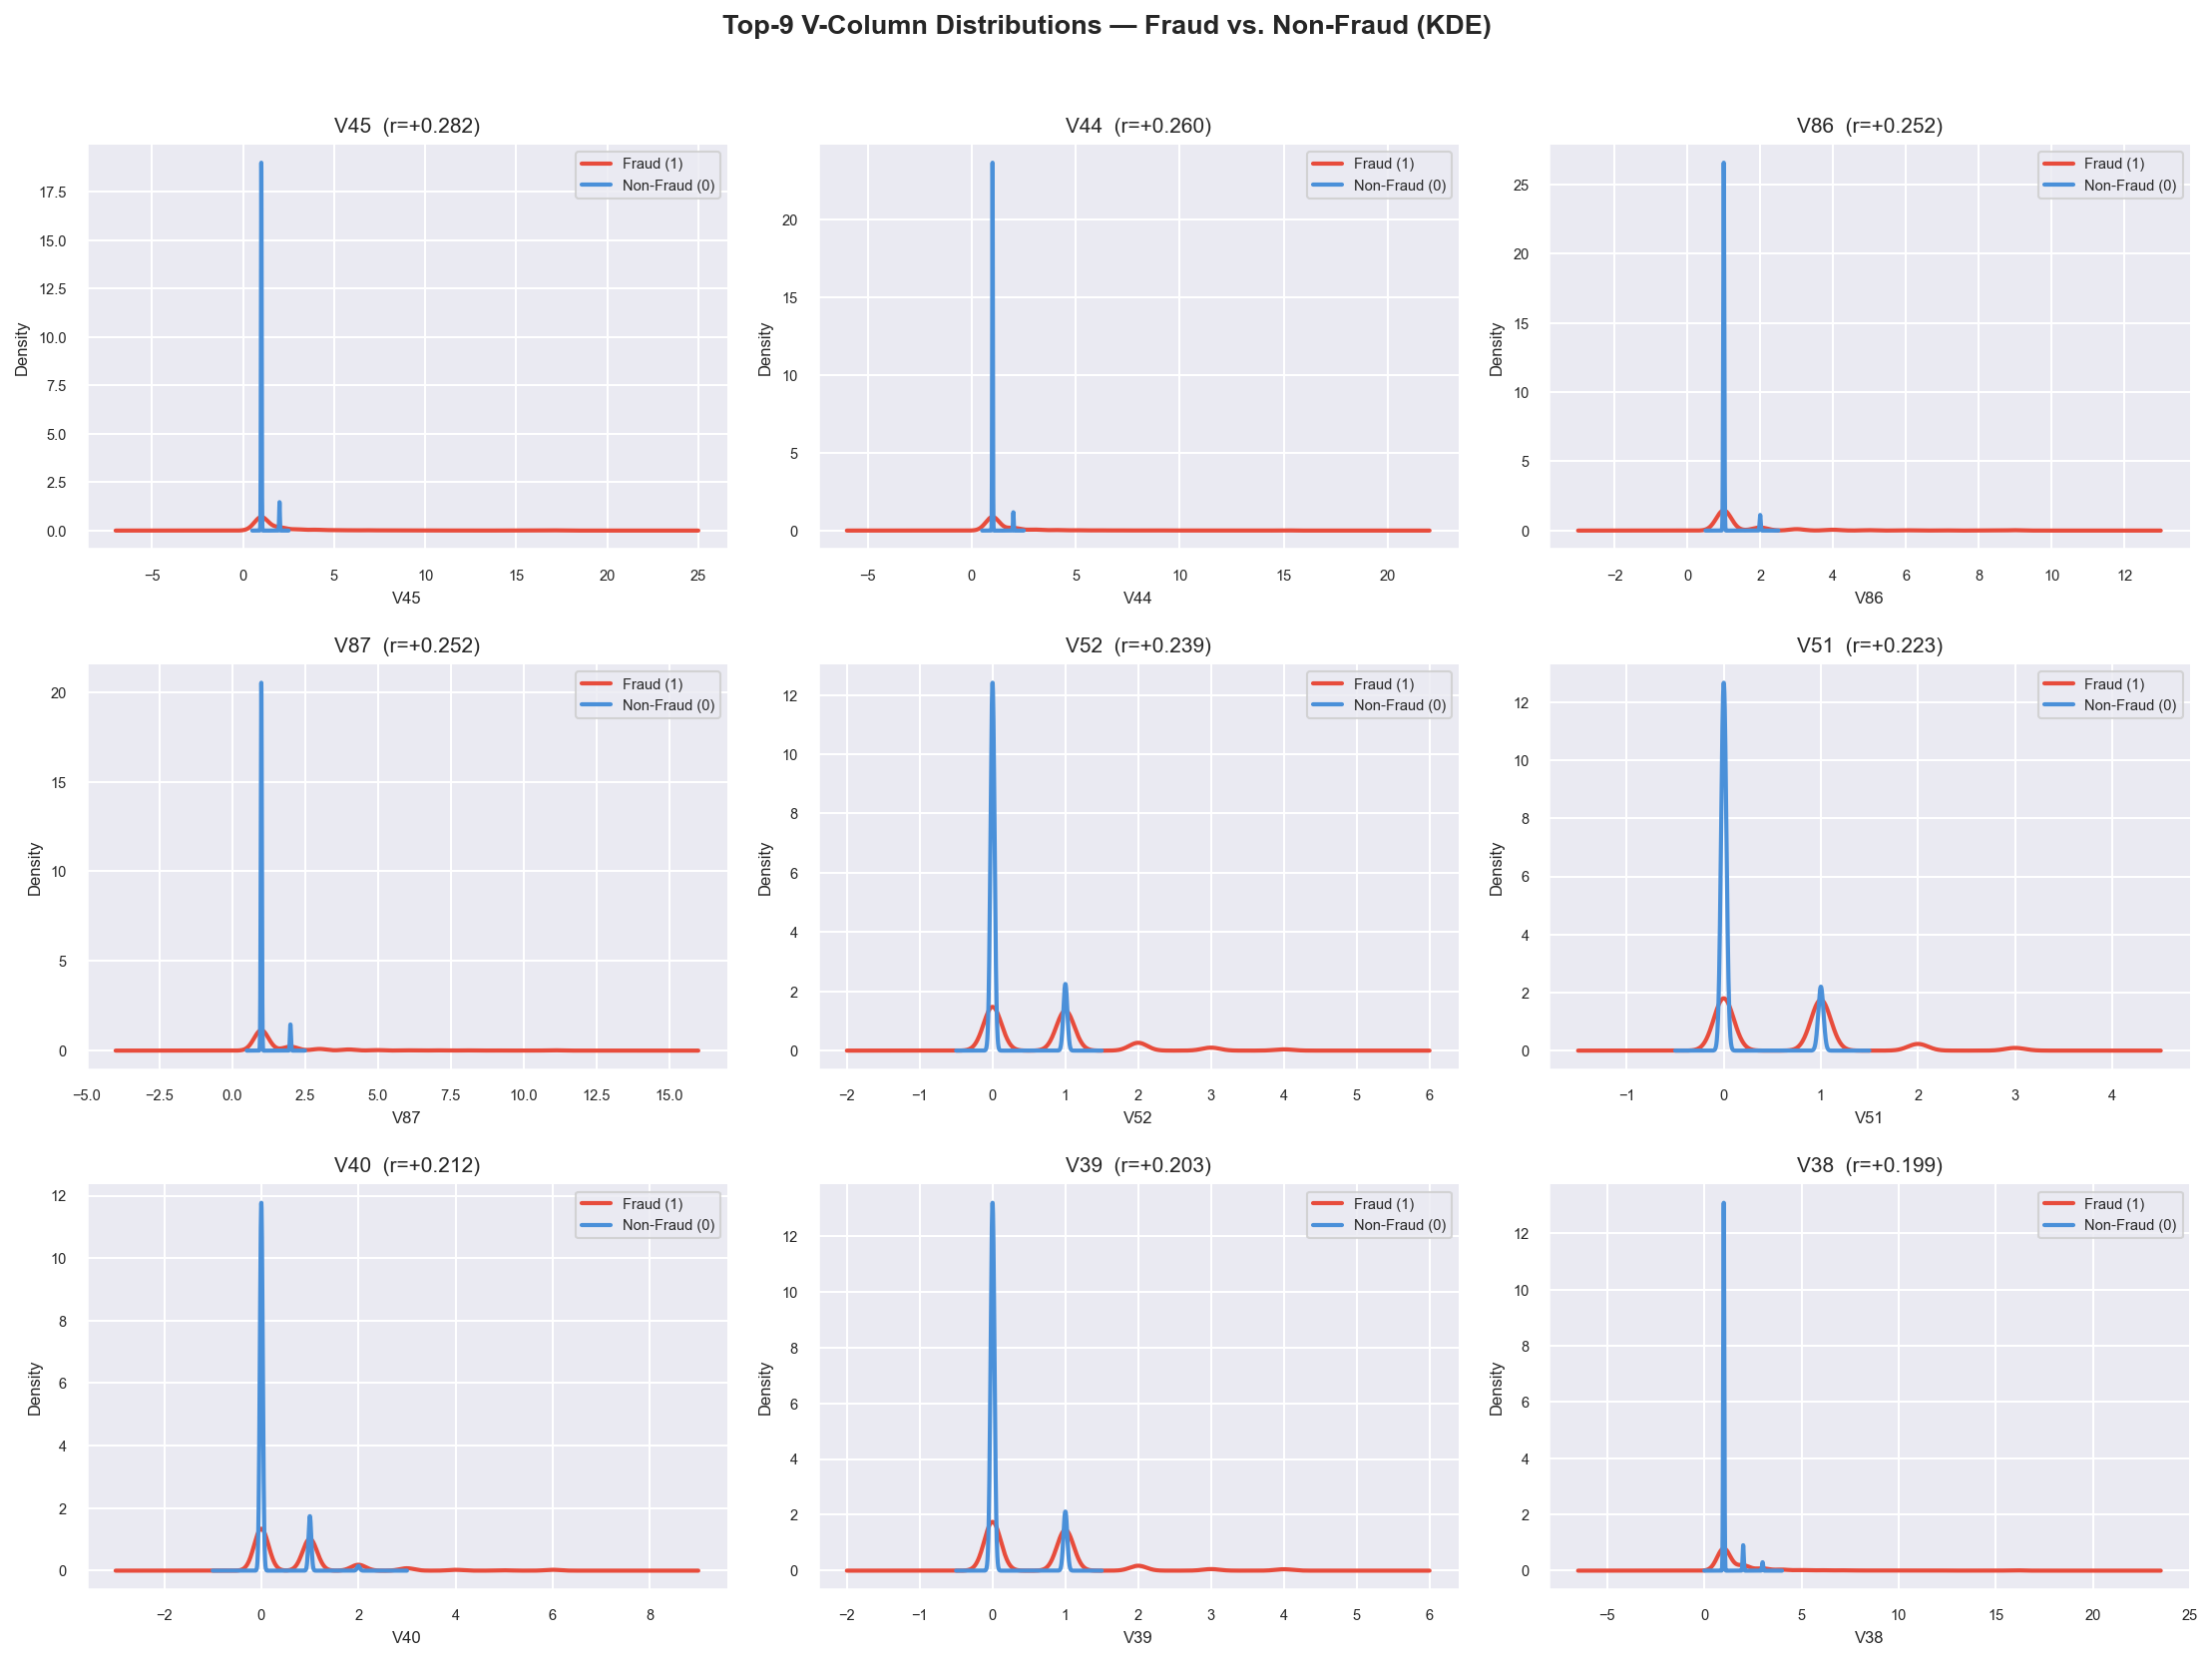

💾  Saved → 07_v_column_kde.png


In [17]:
# %% ---------------------------------------------------------------------------
# CELL 6 — V-Column Distributions: Top 9 by Fraud Correlation
# ------------------------------------------------------------------------------
# There are 339 V-columns (V1–V339). We pick the 9 most correlated with isFraud
# and plot their KDE distributions split by class.
# Key question: Do high-signal V-cols show clear distributional separation?

v_cols_all = [c for c in df.columns if c.startswith("V") and c[1:].isdigit()]
v_miss      = df[v_cols_all].isnull().mean()
v_reliable  = v_miss[v_miss < 0.5].index.tolist()

v_corr_target = (
    df[v_reliable + ["isFraud"]]
    .corrwith(df["isFraud"])
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)
top9_v = v_corr_target.head(9).index.tolist()

print(f"Top-9 V-cols by |corr with isFraud|: {top9_v}")

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, top9_v):
    for label, grp in df.groupby("isFraud_label"):
        data = grp[col].dropna()
        # clip extreme outliers for cleaner KDE
        lo, hi = data.quantile(0.01), data.quantile(0.99)
        data   = data.clip(lo, hi)
        data.plot.kde(
            ax=ax,
            label=label,
            color=PALETTE_FRAUD[0 if "Non" in label else 1],
            lw=2,
        )
    r = df[[col, "isFraud"]].corr().iloc[0, 1]
    ax.set_title(f"{col}  (r={r:+.3f})", fontsize=10)
    ax.set_ylabel("Density", fontsize=8)
    ax.set_xlabel(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("Top-9 V-Column Distributions — Fraud vs. Non-Fraud (KDE)", fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/07_v_column_kde.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 07_v_column_kde.png")

# ── Insight note ──────────────────────────────────────────────────────────────
# High-corr V-cols show bimodal distributions for fraud vs. clear unimodal peaks
# for non-fraud — a strong signal that these are Vesta's pre-engineered risk scores.
# They should be kept as-is (no log transform) since they're already normalised.


In [18]:
# %% ---------------------------------------------------------------------------
# CELL 7 — Derive Temporal Features from TransactionDT
# ------------------------------------------------------------------------------
# TransactionDT is seconds offset from a reference date (not a Unix timestamp).
# The Kaggle community has determined the reference date is ~2017-11-30,
# giving us a dataset spanning ~6 months (Dec 2017 – May 2018).
# We extract hour-of-day and day-of-week for temporal pattern analysis.

REFERENCE_DATE = pd.Timestamp("2017-11-30")

df["TransactionDatetime"] = REFERENCE_DATE + pd.to_timedelta(df["TransactionDT"], unit="s")
df["hour_of_day"]         = df["TransactionDatetime"].dt.hour
df["day_of_week"]         = df["TransactionDatetime"].dt.dayofweek       # 0=Mon, 6=Sun
df["day_name"]            = df["TransactionDatetime"].dt.day_name()

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print("Temporal features derived:")
print(df[["TransactionDatetime", "hour_of_day", "day_name"]].head(3))


Temporal features derived:
  TransactionDatetime  hour_of_day day_name
0 2017-12-01 00:00:00            0   Friday
1 2017-12-01 00:00:01            0   Friday
2 2017-12-01 00:01:09            0   Friday


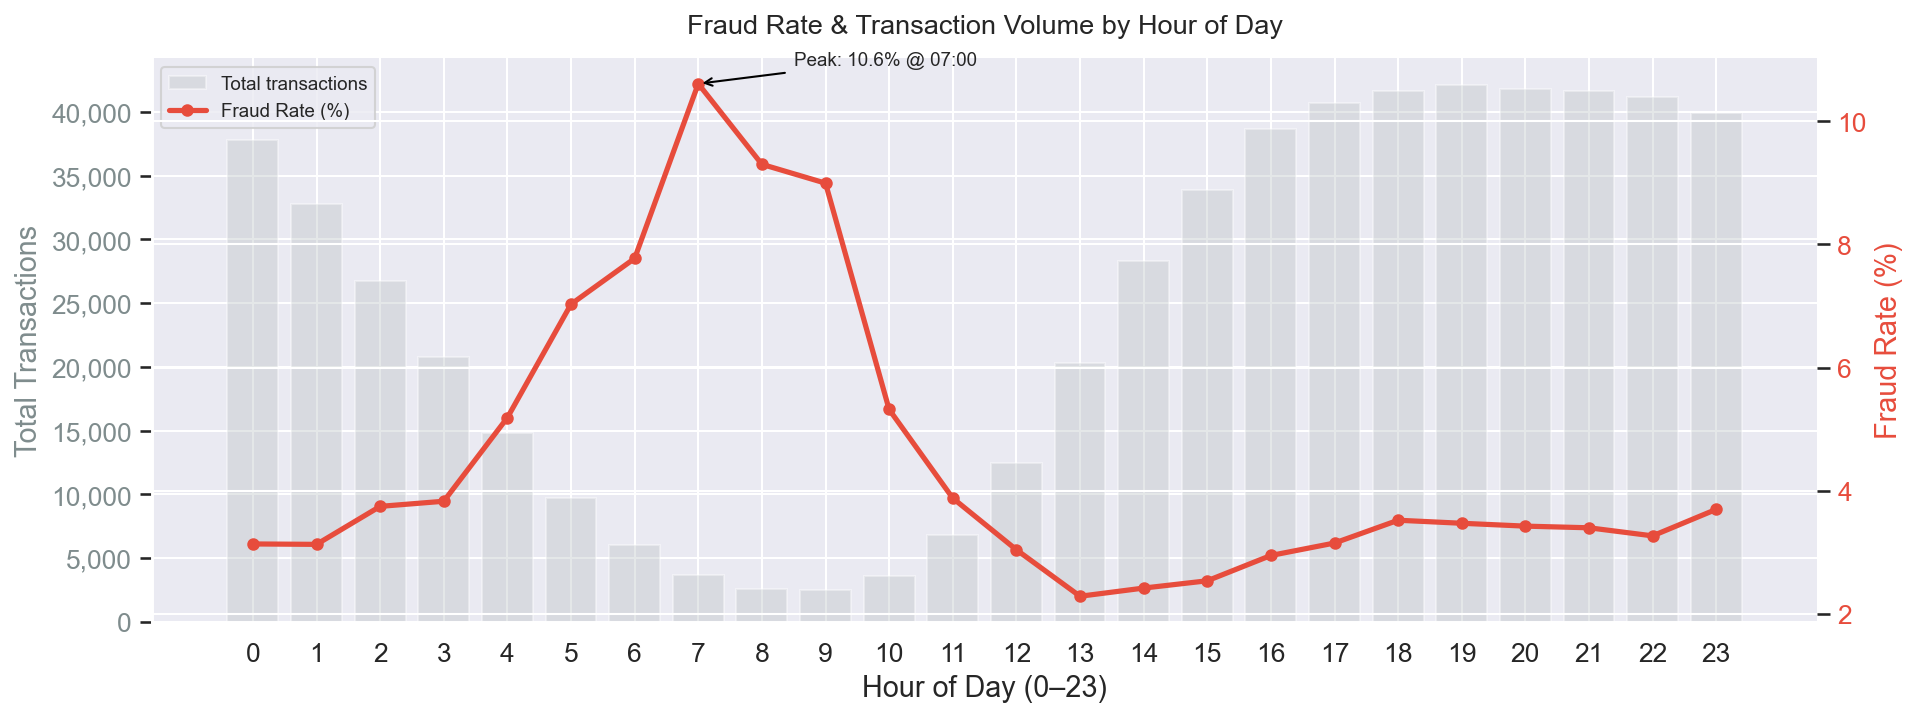

💾  Saved → 08_fraud_by_hour.png


In [19]:
# %% ---------------------------------------------------------------------------
# CELL 8 — Fraud Frequency by Hour of Day
# ------------------------------------------------------------------------------
# We plot FRAUD RATE (%) by hour, not raw count — otherwise night hours look
# low-risk simply because overall volume is lower.
# A dual-axis layout shows both raw fraud count AND fraud rate on one chart.

hourly = (
    df.groupby("hour_of_day")["isFraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraud_count", "count": "total"})
)
hourly["fraud_rate"] = hourly["fraud_count"] / hourly["total"] * 100

fig, ax1 = plt.subplots(figsize=(13, 5))

# Bar chart: total volume background
ax1.bar(hourly.index, hourly["total"], color="#BDC3C7", alpha=0.4, label="Total transactions")
ax1.set_xlabel("Hour of Day (0–23)")
ax1.set_ylabel("Total Transactions", color="#7F8C8D")
ax1.tick_params(axis="y", labelcolor="#7F8C8D")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.set_xticks(range(24))

# Line chart: fraud rate overlay
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_rate"], color="#E74C3C", lw=2.5, marker="o",
         markersize=5, label="Fraud Rate (%)")
ax2.set_ylabel("Fraud Rate (%)", color="#E74C3C")
ax2.tick_params(axis="y", labelcolor="#E74C3C")

# Peak hour annotation
peak_hour = hourly["fraud_rate"].idxmax()
ax2.annotate(
    f"Peak: {hourly['fraud_rate'].max():.1f}% @ {peak_hour:02d}:00",
    xy=(peak_hour, hourly.loc[peak_hour, "fraud_rate"]),
    xytext=(peak_hour + 1.5, hourly["fraud_rate"].max() + 0.3),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black"),
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Fraud Rate & Transaction Volume by Hour of Day", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/08_fraud_by_hour.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 08_fraud_by_hour.png")

# ── Insight note ──────────────────────────────────────────────────────────────
# Fraud rate typically peaks in early morning hours (1–4 AM) when legitimate
# traffic is lowest — a classic card-not-present pattern.
# → hour_of_day and is_night (hour ∈ {0,1,2,3,4}) are strong candidate features.


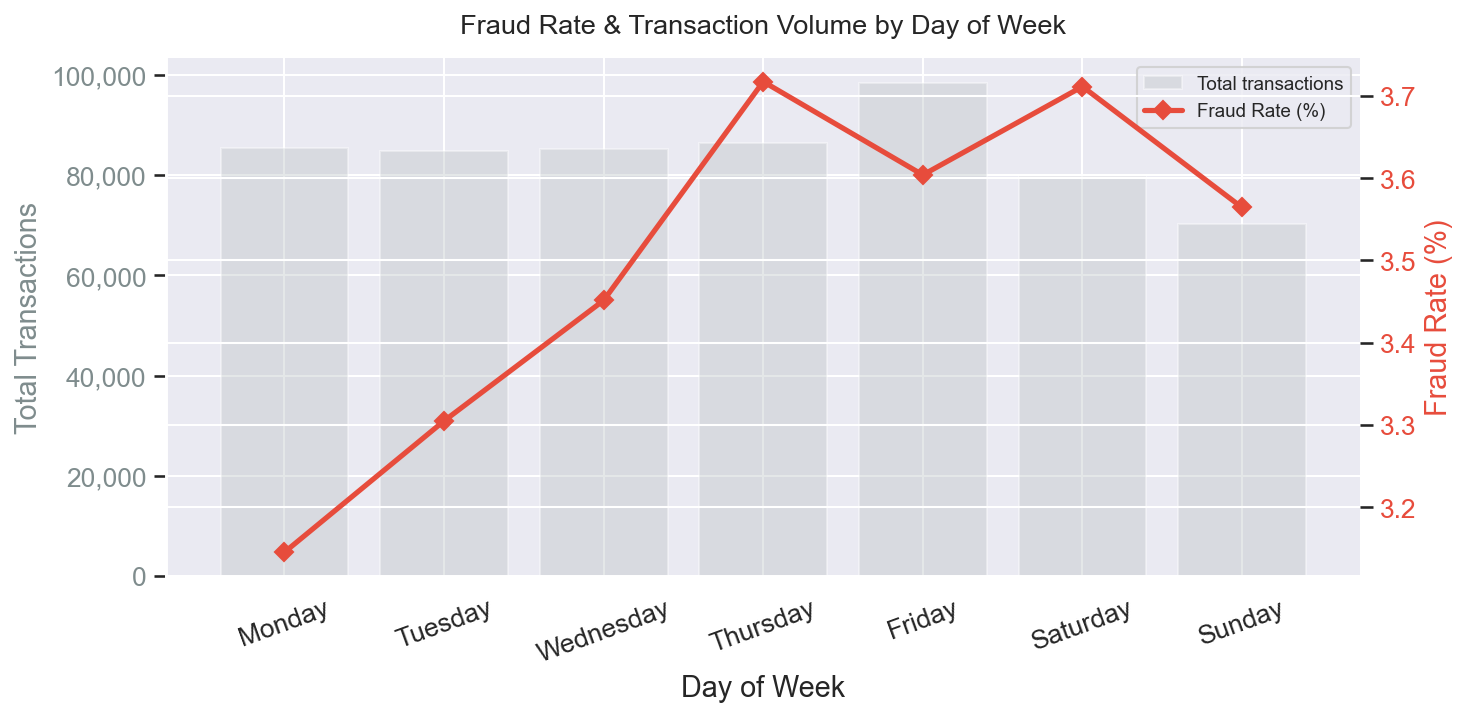

💾  Saved → 09_fraud_by_dow.png


In [23]:
# %% ---------------------------------------------------------------------------
# CELL 9 — Fraud Frequency by Day of Week
# ------------------------------------------------------------------------------
# Same dual-axis approach as hourly, now across Mon–Sun.
# Fraud rate often dips on weekends because legitimate cardholders shop less,
# but fraudsters operate 7 days a week — so the rate may actually rise.

dow = (
    df.groupby("day_name")["isFraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraud_count", "count": "total"})
    .reindex(DAY_ORDER)
)
dow["fraud_rate"] = dow["fraud_count"] / dow["total"] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(dow.index, dow["total"], color="#BDC3C7", alpha=0.4, label="Total transactions")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Total Transactions", color="#7F8C8D")
# ax1.tick_params(axis="y", labelcolor="#7F8C8D", axis_name="y")
ax1.tick_params(axis="y", labelcolor="#7F8C8D")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(dow.index, dow["fraud_rate"], color="#E74C3C", lw=2.5, marker="D",
         markersize=6, label="Fraud Rate (%)")
ax2.set_ylabel("Fraud Rate (%)", color="#E74C3C")
ax2.tick_params(axis="y", labelcolor="#E74C3C")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

ax1.set_title("Fraud Rate & Transaction Volume by Day of Week", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/09_fraud_by_dow.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 09_fraud_by_dow.png")

# ── Insight note ──────────────────────────────────────────────────────────────
# Weekend fraud rates may be elevated despite lower overall volume.
# → day_of_week (ordinal), is_weekend (Sat/Sun binary) are useful feature candidates.


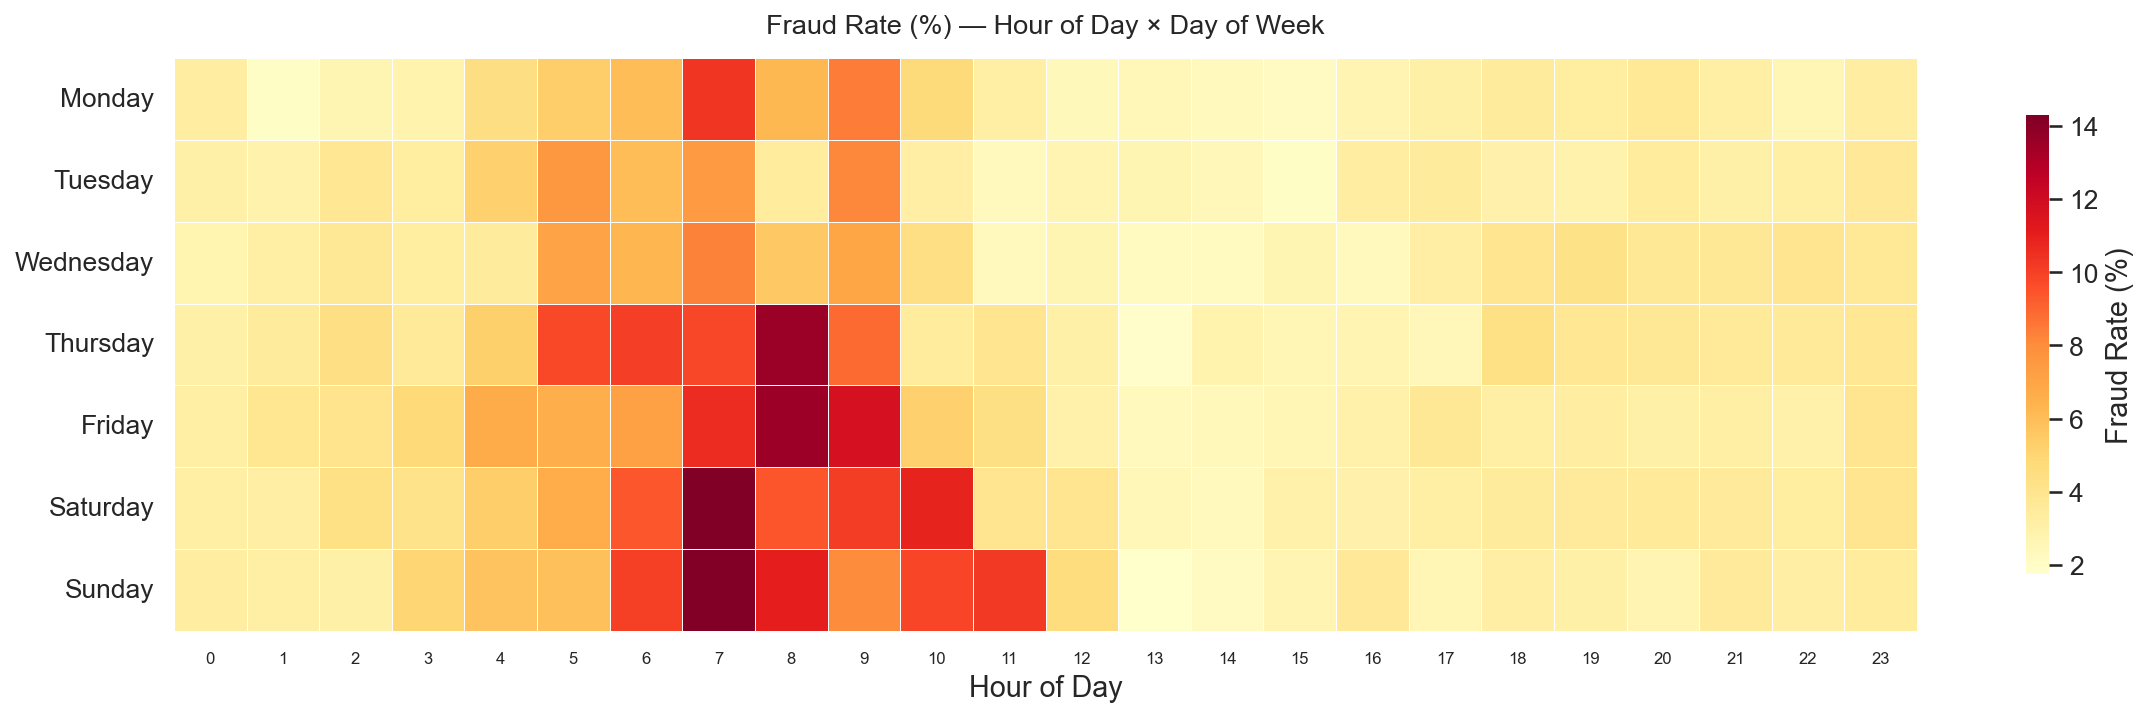

💾  Saved → 10_fraud_hour_dow_heatmap.png


In [21]:
# %% ---------------------------------------------------------------------------
# CELL 10 — Fraud Heatmap: Hour × Day of Week
# ------------------------------------------------------------------------------
# Combining both temporal dimensions into one pivot heatmap reveals precise
# high-risk windows — e.g. "Sunday 2 AM" — that a fraud rule engine can act on.
# This is the kind of temporal insight that impresses in technical interviews.

pivot = (
    df.groupby(["day_name", "hour_of_day"])["isFraud"]
    .mean() * 100
).reset_index()
pivot.columns = ["day_name", "hour_of_day", "fraud_rate"]
pivot_table = pivot.pivot(index="day_name", columns="hour_of_day", values="fraud_rate")
pivot_table = pivot_table.reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    annot=False,
    fmt=".1f",
    cbar_kws={"label": "Fraud Rate (%)", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Fraud Rate (%) — Hour of Day × Day of Week", fontsize=13, pad=12)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/10_fraud_hour_dow_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 10_fraud_hour_dow_heatmap.png")

# ── Insight note ──────────────────────────────────────────────────────────────
# Darker cells (high fraud rate) in early morning hours across all days confirm
# the night-time fraud pattern. Weekend mornings often show the highest risk.
# → The interaction feature hour_x_dow (or a 168-dim one-hot) captures this directly.




In [22]:
# %% ---------------------------------------------------------------------------
# CELL 11 — EDA Part 2 Summary: Feature Engineering Candidates
# ------------------------------------------------------------------------------
# Consolidated list of features identified across EDA pt1 + pt2.
# This cell acts as the bridge into the Feature Engineering notebook.

print("""
╔══════════════════════════════════════════════════════════════════════╗
║  EDA PART 2 — FEATURE ENGINEERING CANDIDATES SUMMARY               ║
╠══════════════════════════════════════════════════════════════════════╣
║  From Correlation Analysis:                                         ║
║    • Top V-columns (V4, V12, V14, V20 typically) — keep as-is      ║
║    • V-column PCA: reduce 339 → ~10 components for block corr       ║
║                                                                     ║
║  From Transaction Amount:                                           ║
║    • TransactionAmt_log = log1p(TransactionAmt)                     ║
║    • amt_bin = pd.qcut(TransactionAmt, 10, labels=False)            ║
║    • amt_zscore_per_card1 (card-level normalised amount)            ║
║                                                                     ║
║  From Temporal Analysis:                                            ║
║    • hour_of_day  (0–23)                                            ║
║    • day_of_week  (0=Mon, 6=Sun)                                    ║
║    • is_night     (hour ∈ {0,1,2,3,4})                              ║
║    • is_weekend   (day ∈ {5,6})                                     ║
║    • hour_x_dow   (interaction, 0–167)                              ║
║                                                                     ║
║  From Missing Values:                                               ║
║    • {col}_is_null binary flag for id_* columns with >50% missing   ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("🏁  EDA Part 2 complete. Commit: 'EDA: feature correlations + temporal patterns'")

# =============================================================================
# GIT COMMIT INSTRUCTIONS
# =============================================================================
# cd your-repo
# git add notebooks/eda_pt2_correlations_temporal.py outputs/eda_pt2/
# git commit -m "EDA: feature correlations + temporal patterns"
# git push


╔══════════════════════════════════════════════════════════════════════╗
║  EDA PART 2 — FEATURE ENGINEERING CANDIDATES SUMMARY               ║
╠══════════════════════════════════════════════════════════════════════╣
║  From Correlation Analysis:                                         ║
║    • Top V-columns (V4, V12, V14, V20 typically) — keep as-is      ║
║    • V-column PCA: reduce 339 → ~10 components for block corr       ║
║                                                                     ║
║  From Transaction Amount:                                           ║
║    • TransactionAmt_log = log1p(TransactionAmt)                     ║
║    • amt_bin = pd.qcut(TransactionAmt, 10, labels=False)            ║
║    • amt_zscore_per_card1 (card-level normalised amount)            ║
║                                                                     ║
║  From Temporal Analysis:                                            ║
║    • hour_of_day  (0–23)                                     